# Paper-ready healthy and unhealthy samples with annotations

This notebook reads the YOLO annotations, automatically selects representative images for every class, overlays bounding boxes, and exports publication-ready figures. Run all cells from either the repository root or the `notebooks/` directory.

In [1]:
from pathlib import Path
import random
import math
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Reproducible configuration
SEED = 42
SPLIT = 'train'         # all manually selected samples below are from train
SAMPLES_PER_CLASS = 3  # number of columns in the paper figure

# OPTIONAL: Choose the exact banana images to display.
# Enter filenames from detection_dataset/images/<SPLIT>. Use [] for automatic selection.
# The order below is the left-to-right order in the exported figure.
SAMPLE_FILES = {
      "healthy": [
        "healthy_0091.jpg",
        "healthy_0095.jpg",
        "healthy_0096.jpg",
    ],
    "unhealthy": [
        "unhealthy_0139.jpg",
        "unhealthy_0166.jpg",
        "unhealthy_0406.jpg",
    ],
}
MIN_BOX_AREA = 0.01    # ignore very tiny boxes when ranking representative images
DPI = 300

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / 'detection_dataset').exists() else cwd.parent
DATASET = ROOT / 'detection_dataset'
OUTPUT_DIR = ROOT / 'paper_figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
assert DATASET.exists(), f'Dataset not found at {DATASET}'
print('Dataset:', DATASET)
print('Figures:', OUTPUT_DIR)

Dataset: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/detection_dataset
Figures: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/paper_figures


In [2]:
# Load class names from data.yaml (supports either a list or an ID:name dictionary).
with open(DATASET / 'data.yaml', encoding='utf-8') as f:
    config = yaml.safe_load(f)

names = config['names']
if isinstance(names, dict):
    class_names = [names[k] for k in sorted(names, key=lambda x: int(x))]
else:
    class_names = list(names)

image_dir = DATASET / 'images' / SPLIT
label_dir = DATASET / 'labels' / SPLIT
assert image_dir.exists() and label_dir.exists(), f'Invalid split: {SPLIT}'

palette = ['#20A387', '#D1495B', '#3A86FF', '#FF9F1C', '#8338EC', '#2A9D8F']
class_colors = {i: palette[i % len(palette)] for i in range(len(class_names))}
print({i: name for i, name in enumerate(class_names)})

{0: 'healthy', 1: 'unhealthy'}


In [3]:
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp']

def find_image(stem):
    for ext in IMAGE_EXTENSIONS:
        path = image_dir / f'{stem}{ext}'
        if path.exists():
            return path
    return None

def read_yolo_label(label_path):
    annotations = []
    if not label_path.exists():
        return annotations
    for line in label_path.read_text(encoding='utf-8').splitlines():
        parts = line.split()
        if len(parts) >= 5:
            cls, xc, yc, bw, bh = map(float, parts[:5])
            annotations.append((int(cls), xc, yc, bw, bh))
    return annotations

def collect_candidates():
    candidates = {i: [] for i in range(len(class_names))}

    for label_path in sorted(
        p for p in label_dir.glob('*.txt')
        if p.name != 'classes.txt'
    ):
        image_path = find_image(label_path.stem)
        if image_path is None:
            continue

        anns = read_yolo_label(label_path)

        for cls_id in set(a[0] for a in anns):
            class_boxes = [
                a for a in anns
                if a[0] == cls_id and a[3] * a[4] >= MIN_BOX_AREA
            ]

            if class_boxes and cls_id in candidates:
                area = sum(a[3] * a[4] for a in class_boxes)
                score = area + 0.02 * min(len(class_boxes), 5)
                candidates[cls_id].append((score, image_path, anns))

    return candidates

def select_representative(candidates, count, seed=SEED):
    rng = random.Random(seed)
    selected = {}
    for cls_id, items in candidates.items():
        items = sorted(items, key=lambda x: x[0], reverse=True)
        pool = items[:max(count, math.ceil(len(items) / 3))]
        selected[cls_id] = rng.sample(pool, min(count, len(pool)))
    return selected

def apply_manual_selection(automatic_selection):
    selected = {cls_id: list(items) for cls_id, items in automatic_selection.items()}
    for cls_id, class_name in enumerate(class_names):
        filenames = SAMPLE_FILES.get(class_name, [])
        if len(filenames) > SAMPLES_PER_CLASS:
            raise ValueError(f'{class_name}: choose at most {SAMPLES_PER_CLASS} files')
        manual = []
        for filename in filenames:
            # Honor an explicitly selected filename even if it belongs to another split.
            matches = [image_dir / filename]
            matches += sorted((DATASET / 'images').glob(f'*/{filename}'))
            image_path = next((path for path in matches if path.exists()), None)
            if image_path is None:
                raise FileNotFoundError(f'Selected image does not exist in any dataset split: {filename}')
            image_split = image_path.parent.name
            annotations = read_yolo_label(DATASET / 'labels' / image_split / f'{image_path.stem}.txt')
            if not any(a[0] == cls_id for a in annotations):
                print(f'Warning: {filename} has no {class_name!r} annotation; skipping it.')
                continue
            manual.append((0, image_path, annotations))
        fallback = [item for item in selected[cls_id] if item[1].name not in filenames]
        selected[cls_id] = (manual + fallback)[:SAMPLES_PER_CLASS]
    return selected

candidates = collect_candidates()
selected = apply_manual_selection(select_representative(candidates, SAMPLES_PER_CLASS))
for cls_id, name in enumerate(class_names):
    chosen = [item[1].name for item in selected[cls_id]]
    print(f'{name}: {chosen}')

healthy: ['healthy_0091.jpg', 'healthy_0095.jpg', 'healthy_0096.jpg']
unhealthy: ['unhealthy_0139.jpg', 'unhealthy_0166.jpg', 'unhealthy_0406.jpg']


In [4]:
def draw_annotations(ax, image, annotations, focus_class=None, show_labels=True):
    width, height = image.size
    ax.imshow(image)
    for cls_id, xc, yc, bw, bh in annotations:
        if focus_class is not None and cls_id != focus_class:
            continue
        x = (xc - bw / 2) * width
        y = (yc - bh / 2) * height
        box_w, box_h = bw * width, bh * height
        color = class_colors[cls_id]
        ax.add_patch(Rectangle((x, y), box_w, box_h, fill=False, edgecolor=color, linewidth=2.2))
        if show_labels:
            ax.text(x, max(0, y - 3), class_names[cls_id].capitalize(), color='white', fontsize=8,
                    weight='bold', va='bottom', ha='left',
                    bbox=dict(facecolor=color, edgecolor='none', alpha=0.92, pad=2))
    ax.axis('off')

def save_figure(fig, filename):
    png_path = OUTPUT_DIR / f'{filename}.png'
    pdf_path = OUTPUT_DIR / f'{filename}.pdf'
    fig.savefig(png_path, dpi=DPI, bbox_inches='tight', facecolor='white')
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    print('Saved:', png_path)
    print('Saved:', pdf_path)

## Figure 1 — annotated examples from every class

Each row is one class. Bounding boxes are ground-truth annotations, not model predictions.

Saved: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/paper_figures/all_classes_annotated_train.png
Saved: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/paper_figures/all_classes_annotated_train.pdf


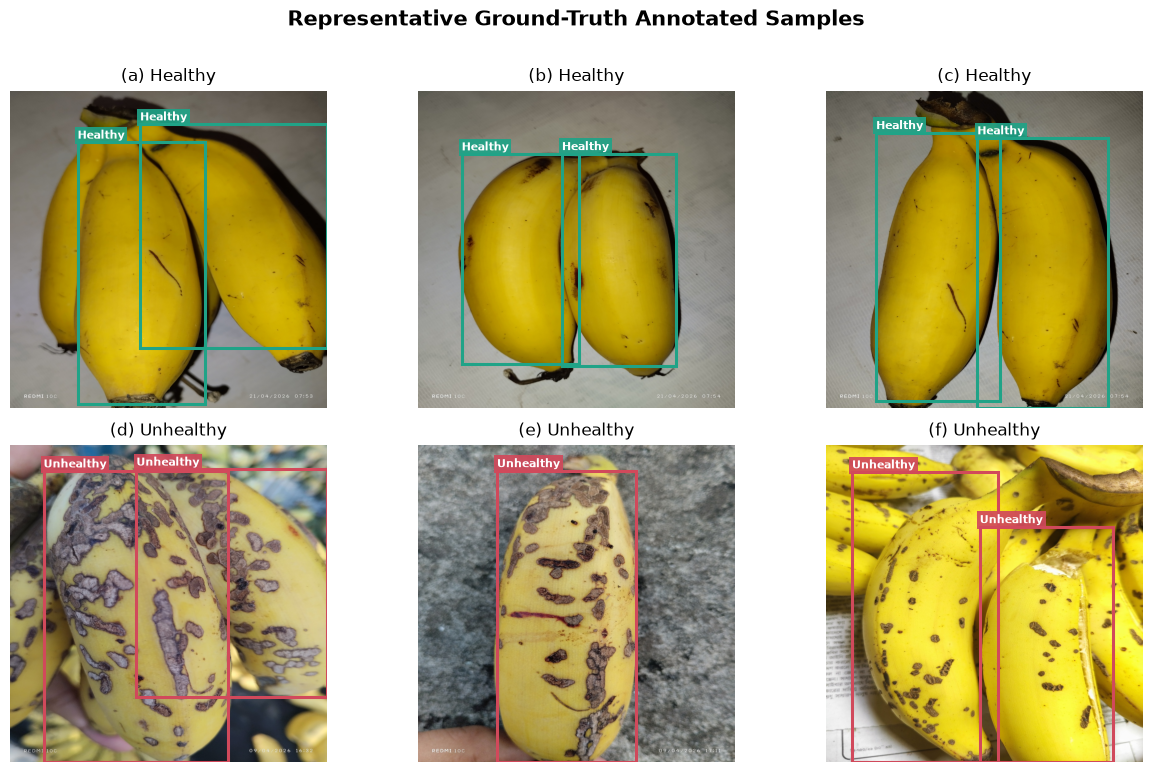

In [5]:
nrows, ncols = len(class_names), SAMPLES_PER_CLASS
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), squeeze=False)

for cls_id, class_name in enumerate(class_names):
    for col in range(ncols):
        ax = axes[cls_id, col]
        if col >= len(selected[cls_id]):
            ax.axis('off')
            continue
        _, image_path, annotations = selected[cls_id][col]
        with Image.open(image_path) as im:
            image = im.convert('RGB')
        draw_annotations(ax, image, annotations, focus_class=cls_id)
        ax.set_title(f'({chr(97 + cls_id * ncols + col)}) {class_name.capitalize()}', fontsize=12, pad=7)

fig.suptitle('Representative Ground-Truth Annotated Samples', fontsize=15, weight='bold', y=1.01)
fig.tight_layout()
save_figure(fig, f'all_classes_annotated_{SPLIT}')
plt.show()

## Figure 2 — original image beside its annotation

This layout makes the annotation process visually explicit and can be used as a dataset-methodology figure.

Saved: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/paper_figures/original_vs_annotation_train.png
Saved: /home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/paper_figures/original_vs_annotation_train.pdf


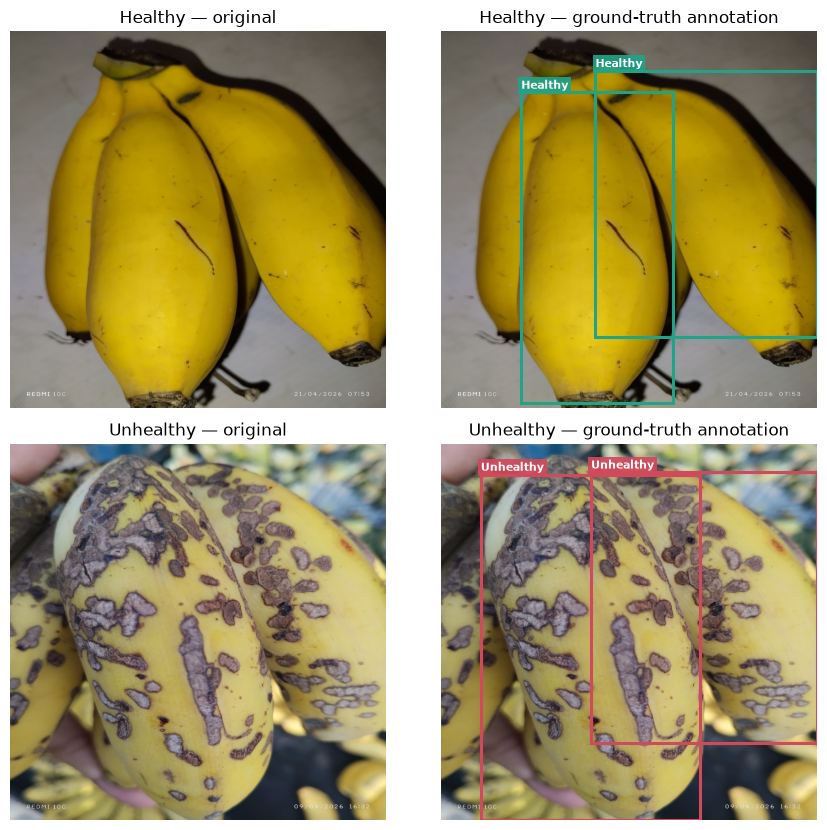

In [6]:
fig, axes = plt.subplots(len(class_names), 2, figsize=(9, 4.2 * len(class_names)), squeeze=False)

for cls_id, class_name in enumerate(class_names):
    if not selected[cls_id]:
        axes[cls_id, 0].axis('off')
        axes[cls_id, 1].axis('off')
        continue
    _, image_path, annotations = selected[cls_id][0]
    with Image.open(image_path) as im:
        image = im.convert('RGB')

    axes[cls_id, 0].imshow(image)
    axes[cls_id, 0].axis('off')
    axes[cls_id, 0].set_title(f'{class_name.capitalize()} — original', fontsize=12)

    draw_annotations(axes[cls_id, 1], image, annotations, focus_class=cls_id)
    axes[cls_id, 1].set_title(f'{class_name.capitalize()} — ground-truth annotation', fontsize=12)

fig.tight_layout()
save_figure(fig, f'original_vs_annotation_{SPLIT}')
plt.show()

### Suggested paper captions

**Figure 1.** Representative samples of healthy and unhealthy banana classes from the dataset. Colored bounding boxes show the ground-truth object annotations used for training and evaluation.

**Figure 2.** Examples of original images (left) and their corresponding ground-truth YOLO bounding-box annotations (right) for each class.